In [1]:
from keras.utils import pad_sequences


In [2]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten,Input,Dropout
from keras.callbacks import EarlyStopping

In [3]:
(X_train,y_train),(X_test,y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train = pad_sequences(X_train,padding='post')
X_test = pad_sequences(X_test,padding='post')

In [5]:
X_train.shape

(25000, 2494)

In [6]:

len(X_train[0])

2494

In [7]:
vocab_size = max(max(sequence) for sequence in X_train) + 1
print(vocab_size)


88587


In [8]:
model = Sequential()
model.add(Embedding(88588, 2, input_length=2494))
model.add(SimpleRNN(32,return_sequences=False))

model.add(Dense(1, activation='sigmoid'))


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model2 = Sequential([
    Input(shape=(2494,)),
    Embedding(88588, 2),
    SimpleRNN(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 2494, 2)        │       177,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,329 (696.60 KB)

 Trainable params: 178,329 (696.60 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model2.fit(X_train, y_train,epochs=5,validation_data=(X_test,y_test),callbacks=[EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)])

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 794s 1s/step - acc: 0.4901 - loss: 0.6940 - val_acc: 0.5000 - val_loss: 0.6934
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 792s 1s/step - acc: 0.4943 - loss: 0.6980 - val_acc: 0.5000 - val_loss: 0.6932
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 805s 1s/step - acc: 0.5019 - loss: 0.7029 - val_acc: 0.5000 - val_loss: 0.6932
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 803s 1s/step - acc: 0.5011 - loss: 0.6961 - val_acc: 0.5000 - val_loss: 0.6941


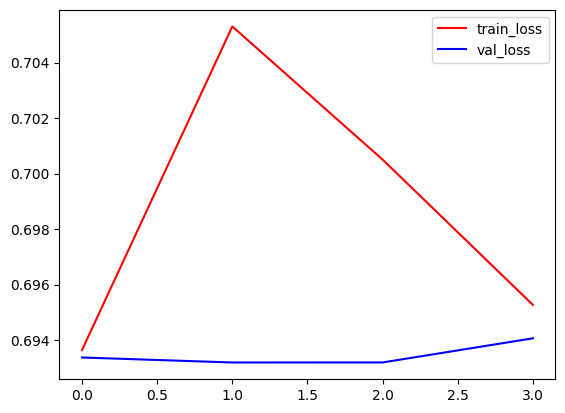

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train_loss')
plt.plot(history.history['val_loss'],color='blue',label='val_loss')
plt.legend()
plt.show()

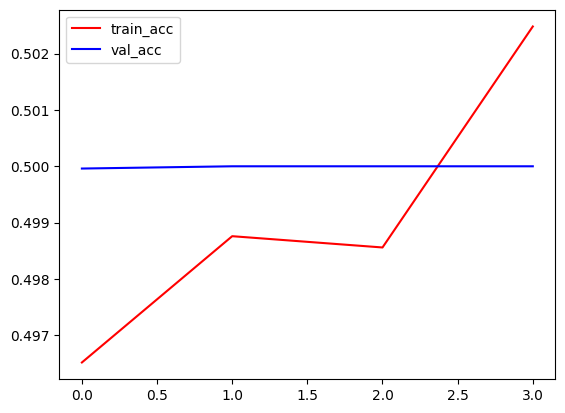

In [12]:
plt.plot(history.history['acc'],color='red',label='train_acc')
plt.plot(history.history['val_acc'],color='blue',label='val_acc')
plt.legend()
plt.show()